# 30 — Abundance by geologic unit (Tanaka SIM3292)

**The question.** Does the shipped 160 m rock-abundance map vary with *mapped geology*? If it
does — and in a direction geology predicts — that is independent evidence the map is measuring
Mars. If it does not, either the map is not resolving a real signal or geologic unit is the
wrong explanatory variable at this scale. [PLAN_MapValidation](../PLAN_MapValidation.md) §10
committed to both readings **in advance**, so this cannot be graded after the fact.

**The data.** Tanaka et al. (2014), *Geologic Map of Mars*, USGS SIM 3292 — 1311 polygons,
44 units globally. DOI [10.3133/sim3292](https://doi.org/10.3133/sim3292).

**The map.** `reports/map_union` — the deduplicated read surface over every shipped arm
(`scripts/map_union.py`). It is **growable**: this notebook reads its tile count from the
product, so adding map tiles never edits an analysis.

**Three targets throughout** (PLAN_MapValidation ruling 3), because a result that holds on all
three is robust and one that appears only in `abundance` is likely a calibration-curve artifact:

| target | what it is |
|---|---|
| `abundance` | calibrated areal boulder fraction — *size-floor-referenced* (see caveats) |
| `prob_raw` | uncalibrated head output; the layer every striping/THEMIS diagnostic used |
| `rich` | share of cells with calibrated `prob >= 0.5` (ruling 4, notebook 24's convention) |

**Two rulings made at execution time, 2026-08-29, with the real distributions in hand:**

1. **Reportability floor = 50,000 mapped cells** (1,280 km² at 160 m). A unit below it is
   **flagged and excluded from the headline ranking, never silently dropped**.
2. **The headline statistic is the rich fraction**, with mean abundance beside it. The pooled
   *median* `abundance` is **0.0** for most units — zero-cell fractions run from 1.6% to 80.7% —
   so a median ranking would be mostly ties at zero. That is the zero-inflation caveat
   (CLAUDE.md) biting, not a defect of the map.

*(Companions: [24](24_regional_map.ipynb) is the regional-map home,
[29](29_map_comparison.ipynb) compares the shipped maps, and notebook 31 does craters.)*


In [1]:
import json
import sys
import time
from pathlib import Path

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
import matplotlib
import matplotlib.pyplot as plt
from rasterio.transform import array_bounds

from src import map_validation as mv

FIG = REPO / "reports" / "figures"
FIG.mkdir(parents=True, exist_ok=True)
matplotlib.rcParams.update({"figure.dpi": 110, "savefig.dpi": 140,
                            "font.size": 9, "axes.grid": True,
                            "grid.alpha": 0.25, "axes.axisbelow": True})
pd.set_option("display.width", 160, "display.max_columns", 50)
print("union dir:", mv.UNION_DIR.relative_to(REPO))
print("min cells for a reportable unit:", f"{mv.MIN_CELLS_UNIT:,}",
      f"= {mv.MIN_CELLS_UNIT * (mv.PX_M / 1000) ** 2:,.0f} km2")


union dir: reports\map_union
min cells for a reportable unit: 50,000 = 1,280 km2


In [2]:
from IPython.display import Markdown, display

# ONE caveat string, in src/, quoted verbatim by all five validation notebooks -- so the
# caveats cannot drift apart between notebooks or quietly soften over time.
display(Markdown(mv.CAVEAT_MD))


> ### Standing caveats — these apply to every result in this notebook
>
> **1. The CTX source-frame striping artifact is present and UNCORRECTED.** The map inherits
> rectangular, frame-shaped structure from per-frame CTX radiometry (cause solved; no
> mitigation survives — A1 was demoted to a sensitivity arm on 2026-08-25). Per
> PLAN_MapValidation ruling 2 this is **not controlled for here**: no rotation nulls, no A1
> arm. Quantifying and correcting it is a **separate investigation**, with notebook 32 as its
> entry point. **Consequence: every contrast below is an UPPER BOUND on the geologic signal.**
>
> **2. `abundance` is size-floor-referenced, not absolute rock abundance.** It is the area
> share of boulders above a *per-image* detection floor (1.563–5.572 m², i.e. 1.41–2.66 m
> diameter) mixed over 20 floors / 38 images (`v2_mixed_floor_2`, `models/deployable_g2`). It
> is **not** size-independent rock abundance — which matters most in notebook 33, where
> TES/IRTM rock abundance is a genuinely different physical quantity.
>
> **3. Truth coverage thins fast outside circum-Chryse.** 23 of the 39-image training cohort
> sit inside the shipped 26-tile block; only 1 sits in the new southern block. Any claim about
> `map_extended` terrain is **extrapolation**, and captions must say so.
>
> **4. Map cells ≠ label cells.** The map grid is globally anchored (R01); the Stage-4 label
> grid stays tile-anchored. A map↔label comparison must resample, never index-match.
>
> **5. Never presence AUC.** Skill-like numbers use the rich/poor threshold `fa > 1e-2`
> family (`meaningful_auc` / `pr_auc@1e-2` / `precision@5%`), plus Spearman ρ and per-bin RMSE.

## §1 — Coverage: what is actually being compared

Two accounts have to close before any contrast means anything.

1. **The geology must tile the map.** SIM3292 is a complete partition of Mars, so the polygons
   clipped to the union bbox must sum to the bbox area exactly. A shortfall would mean the
   reprojection ate area.
2. **Every mapped cell must land in exactly one unit.** The sum of per-polygon cell counts must
   equal the union's finite-cell count.

⚠ **The reprojection trap, and why `src.map_validation.load_geology` exists.** SIM3292 ships in
**Robinson**, where all 1311 polygons are valid. But the *inverse* Robinson overflows to `inf`
for **62** of them (vertices at |lon| → 180), `make_valid` then **crashes**, and — worse —
`.intersects()` on a non-finite geometry returns *garbage* behind nothing louder than a
`RuntimeWarning`. A naive `to_crs(...).clip(...)` therefore produces a plausible, wrong polygon
set. (PLAN_MapValidation's planning-stage "67 polygons / 16 units" was measured that way and is
superseded by what this cell prints.) The loader selects and clips **in Robinson first**, then
reprojects — see its docstring for the four-step order.


In [3]:
t0 = time.time()
tg = mv.three_targets()          # abundance + prob_raw + rich on ONE shared finite mask
targets = tg.as_dict()
BOUNDS = array_bounds(tg.finite.shape[0], tg.finite.shape[1], tg.transform)
LONLAT = mv.bounds_lonlat(BOUNDS)

print(f"union: {tg.meta['n_union_tiles']} tiles, {tg.finite.shape[0]}x{tg.finite.shape[1]} cells, "
      f"loaded in {time.time() - t0:.0f}s")
print(f"  finite (shared across all three targets): {tg.n_finite:,} "
      f"({tg.n_finite / tg.finite.size:.2%} of the bbox)")
print(f"  bbox: lon [{LONLAT[0]:.2f}, {LONLAT[2]:.2f}]  lat [{LONLAT[1]:.2f}, {LONLAT[3]:.2f}]")
print(f"  size-floor basis: {tg.meta['size_floor'].get('SIZE_FLOOR_BASIS_VERSION')} "
      f"(min {tg.meta['size_floor'].get('SIZE_FLOOR_GLOBAL_MIN_SIZE_M')} m)")
print(f"  tiles adopted from another arm: {len(tg.meta['adopted_tiles'])}")


union: 122 tiles, 11852x28153 cells, loaded in 8s


  finite (shared across all three targets): 265,850,879 (79.67% of the bbox)
  bbox: lon [-56.00, 20.00]  lat [16.00, 48.00]
  size-floor basis: v2_mixed_floor_2 (min 1.4105 m)
  tiles adopted from another arm: 8


In [4]:
geo, rep = mv.load_geology(BOUNDS, tg.crs_wkt)

print("SIM3292:", rep["source_polygons"], "polygons /", rep["source_units"],
      "units, source CRS", rep["source_crs"])
print(f"  invalid at source: {rep['source_invalid']}   non-finite at source: "
      f"{rep['source_nonfinite']}")
print(f"  selected in source CRS: {rep['selected_in_source_crs']}")
print(f"  non-finite after the Robinson clip: {rep['nonfinite_after_source_clip']}  "
      f"after reprojection: {rep['nonfinite_after_reprojection']}")
print(f"  geometries repaired: {rep['repaired']}   still invalid: "
      f"{rep['invalid_after_repair']}")
print(f"\nIN THE UNION BBOX: {rep['polygons']} polygons / {rep['units']} units")
print(f"  PARTITION CLOSURE: {rep['area_km2_total']:,.0f} km2 of a "
      f"{rep['bbox_area_km2']:,.0f} km2 bbox = {rep['partition_closure']:.8f}")
assert abs(rep["partition_closure"] - 1.0) < 1e-6, (
    "the geology does not tile the union bbox -- the reprojection lost area, and every "
    "per-unit statistic below would be over a footprint we cannot account for")
assert rep["nonfinite_after_reprojection"] == 0


SIM3292: 1311 polygons / 44 units, source CRS Robinson_clon0_Mars_2000_Sphere
  invalid at source: 0   non-finite at source: 0
  selected in source CRS: 79
  non-finite after the Robinson clip: 0  after reprojection: 0
  geometries repaired: 0   still invalid: 0

IN THE UNION BBOX: 75 polygons / 14 units
  PARTITION CLOSURE: 8,541,848 km2 of a 8,541,848 km2 bbox = 1.00000000


In [5]:
# The zonal pass: one geometry mask per polygon, all three targets read from the SAME cells.
# Only MOMENTS are kept, not cell arrays -- 265.8 M cells would be ~2 GB per target, and
# subsampling would silently change the estimator (weighting small polygons like large ones).
# Means and rich fractions are ratios of sums, so moments give the EXACT statistic (see
# mv.cluster_bootstrap_ratio_ci). A bounded random subsample is kept purely for the ECDFs.
ECDF_MAX = 20_000
rng = np.random.default_rng(0)
rows, ecdf = [], {}
t0 = time.time()
for i, r in geo.iterrows():
    vals = mv.zonal_cells(r.geometry, targets, tg.transform)
    ab, praw, rich = vals["abundance"], vals["prob_raw"], vals["rich"]
    row = {"poly": int(i), "Unit": r["Unit"], "UnitDesc": r["UnitDesc"],
           "area_km2": float(r["area_km2"]), "n_cells": int(ab.size)}
    for name, v in (("ab", ab), ("praw", praw), ("rich", rich)):
        row[f"{name}_sum"] = float(v.sum()) if v.size else 0.0
        row[f"{name}_sumsq"] = float((v ** 2).sum()) if v.size else 0.0
    if ab.size:
        row["ab_zero_frac"] = float((ab == 0).mean())
        for p in (50, 75, 90, 99):
            row[f"ab_p{p}"] = float(np.percentile(ab, p))
            row[f"praw_p{p}"] = float(np.percentile(praw, p))
        take = ab if ab.size <= ECDF_MAX else rng.choice(ab, ECDF_MAX, replace=False)
        ecdf[int(i)] = np.sort(take.astype(np.float32))
    rows.append(row)
poly = pd.DataFrame(rows)
print(f"zonal pass over {len(poly)} polygons in {time.time() - t0:.1f}s")

# account 2: every mapped cell lands in exactly one unit
assert int(poly.n_cells.sum()) == tg.n_finite, (
    f"cells in polygons {poly.n_cells.sum():,} != union finite {tg.n_finite:,}")
print(f"CELL ACCOUNT CLOSES: {poly.n_cells.sum():,} = union finite {tg.n_finite:,}")
print(f"  polygons with 0 mapped cells: {int((poly.n_cells == 0).sum())} of {len(poly)} "
      "(they fall in the union's nodata)")


zonal pass over 75 polygons in 19.0s


CELL ACCOUNT CLOSES: 265,850,879 = union finite 265,850,879
  polygons with 0 mapped cells: 12 of 75 (they fall in the union's nodata)


In [6]:
# per-unit rollup. Note `ab_mean` / `rich_frac` are cell-weighted (sum/count), NOT the
# mean of per-polygon means -- a unit's value is a statement about its ground, not about how
# the mapmakers happened to split it into polygons.
def rollup(df):
    g = df.groupby("Unit", as_index=False).agg(
        polys=("poly", "size"), polys_mapped=("n_cells", lambda s: int((s > 0).sum())),
        area_km2=("area_km2", "sum"), n_cells=("n_cells", "sum"),
        ab_sum=("ab_sum", "sum"), praw_sum=("praw_sum", "sum"), rich_sum=("rich_sum", "sum"))
    g["ab_mean"] = g.ab_sum / g.n_cells.replace(0, np.nan)
    g["praw_mean"] = g.praw_sum / g.n_cells.replace(0, np.nan)
    g["rich_frac"] = g.rich_sum / g.n_cells.replace(0, np.nan)
    g["reportable"] = g.n_cells >= mv.MIN_CELLS_UNIT
    st = g.Unit.map(lambda u: mv.stratigraphic_rank(u))
    g["age_rank"] = [s["rank"] for s in st]
    g["age_label"] = [s["label"] for s in st]
    g["spans_epochs"] = [s["spans"] for s in st]
    return g.sort_values("rich_frac", ascending=False).reset_index(drop=True)

units = rollup(poly)
show = ["Unit", "polys", "polys_mapped", "n_cells", "area_km2", "ab_mean", "praw_mean",
        "rich_frac", "reportable", "age_label", "spans_epochs"]
print(units[show].to_string(index=False,
      formatters={"n_cells": "{:,.0f}".format, "area_km2": "{:,.0f}".format,
                  "ab_mean": "{:.5f}".format, "praw_mean": "{:.4f}".format,
                  "rich_frac": "{:.4f}".format}))
notrep = units[~units.reportable]
print(f"\nBELOW THE {mv.MIN_CELLS_UNIT:,}-CELL FLOOR -- flagged, excluded from the headline "
      f"ranking, NOT dropped: {list(notrep.Unit) or 'none'}")
for _, r in notrep.iterrows():
    print(f"  {r.Unit:5s} {r.n_cells:>10,.0f} cells from {r.polys_mapped}/{r.polys} mapped "
          f"polygons over {r.area_km2:,.0f} km2 of bbox area -- {r.UnitDesc if 'UnitDesc' in r else ''}")


Unit  polys  polys_mapped    n_cells  area_km2 ab_mean praw_mean rich_frac  reportable             age_label  spans_epochs
 eHh      1             1     48,633     1,252 0.01199    0.4646    0.3892       False       Early Hesperian         False
 mAl      2             2  4,205,540   108,191 0.01086    0.3822    0.2848        True      Middle Amazonian         False
 lNh     11             9 17,387,190   768,255 0.01227    0.3105    0.2550        True         Late Noachian         False
 lHl      2             2 82,467,662 2,134,614 0.00801    0.2758    0.2058        True        Late Hesperian         False
 eHt      5             5 22,268,200   594,277 0.00491    0.1884    0.1136        True       Early Hesperian         False
 Hto      2             2 35,826,544   923,155 0.00259    0.1193    0.0580        True Hesperian (undivided)         False
 lHt      4             4 11,546,761   299,153 0.00186    0.0894    0.0332        True        Late Hesperian         False
 mNh      6     

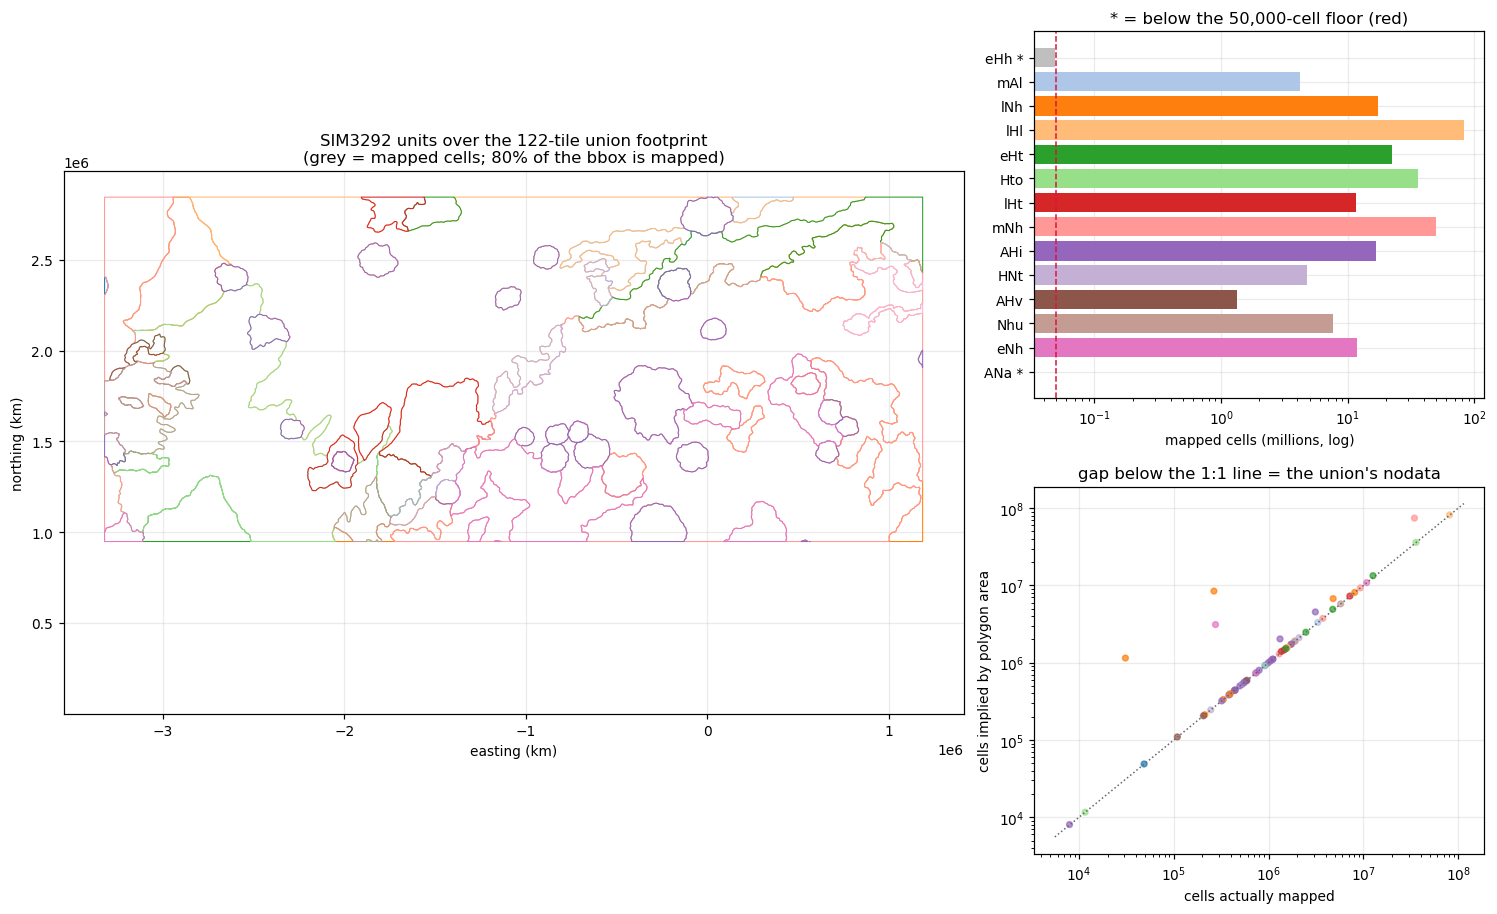

In [7]:
# Figure 1: coverage. Where each unit is, and how much of the map it holds.
fig = plt.figure(figsize=(13.5, 8.2), constrained_layout=True)
gs = fig.add_gridspec(2, 2, width_ratios=[2.0, 1.0], height_ratios=[1.0, 1.0])

axm = fig.add_subplot(gs[:, 0])
order = list(units.Unit)
cmap = plt.get_cmap("tab20")
colors = {u: cmap(k % 20) for k, u in enumerate(order)}
# the mapped footprint underneath, so nodata is visible as nodata
axm.imshow(tg.finite, extent=(BOUNDS[0] / 1e3, BOUNDS[2] / 1e3, BOUNDS[1] / 1e3,
                              BOUNDS[3] / 1e3), origin="upper", cmap="Greys", vmin=0, vmax=3,
           interpolation="nearest")
for u in order:
    sub = geo[geo.Unit == u]
    gpd.GeoSeries(sub.geometry.values, crs=tg.crs_wkt).boundary.plot(
        ax=axm, color=colors[u], linewidth=0.7)
axm.set_xlabel("easting (km)")
axm.set_ylabel("northing (km)")
axm.set_title(f"SIM3292 units over the {tg.meta['n_union_tiles']}-tile union footprint\n"
              f"(grey = mapped cells; {tg.n_finite / tg.finite.size:.0%} of the bbox is mapped)")
axm.set_aspect("equal")

axb = fig.add_subplot(gs[0, 1])
rep_mask = units.reportable.values
axb.barh(range(len(units)), units.n_cells / 1e6,
         color=[colors[u] if m else "0.75" for u, m in zip(units.Unit, rep_mask)])
axb.set_yticks(range(len(units)))
axb.set_yticklabels([f"{u}{'' if m else ' *'}" for u, m in zip(units.Unit, rep_mask)])
axb.invert_yaxis()
axb.set_xscale("log")
axb.axvline(mv.MIN_CELLS_UNIT / 1e6, color="crimson", ls="--", lw=1)
axb.set_xlabel("mapped cells (millions, log)")
axb.set_title(f"* = below the {mv.MIN_CELLS_UNIT:,}-cell floor (red)")

axz = fig.add_subplot(gs[1, 1])
sub = poly[poly.n_cells > 0]
axz.scatter(sub.n_cells, sub.area_km2 * 1e6 / (mv.PX_M ** 2), s=14, alpha=0.7,
            c=[colors[u] for u in sub.Unit])
lim = [sub.n_cells.min() * 0.7, sub.area_km2.max() * 1e6 / (mv.PX_M ** 2) * 1.4]
axz.plot(lim, lim, color="0.4", lw=1, ls=":")
axz.set_xscale("log"); axz.set_yscale("log")
axz.set_xlabel("cells actually mapped")
axz.set_ylabel("cells implied by polygon area")
axz.set_title("gap below the 1:1 line = the union's nodata")
fig.savefig(FIG / "30_geology_coverage.png", bbox_inches="tight")
plt.show()


## §2 — Pooled distributions per unit (ruling 9a)

The headline ranking is on **rich fraction** (share of cells with calibrated `prob >= 0.5`),
with **mean abundance** beside it and the **full ECDFs** behind both.

**Why not the median.** The target is heavily zero-inflated and right-skewed (CLAUDE.md); the
pooled median `abundance` is exactly 0.0 for most units, so a median ranking is mostly ties at
zero. That is a property of the quantity, not a defect of the map — but it does mean the median
is the wrong instrument here.

**Where the error bars come from (ruling 5).** Never the cell count. The CIs are a **cluster
bootstrap over polygons** — resample the unit's polygons with replacement and pool all their
cells. Both statistics are ratios of sums, so this is exact from per-polygon moments
(`mv.cluster_bootstrap_ratio_ci`). A unit with one mapped polygon gets **no CI**, reported as
undefined rather than as a zero-width interval implying certainty.


In [8]:
N_BOOT = 4000
ci_rows = []
for u in units.Unit:
    sub = poly[poly.Unit == u]
    for stat, col in (("rich_frac", "rich_sum"), ("ab_mean", "ab_sum"),
                      ("praw_mean", "praw_sum")):
        ci = mv.cluster_bootstrap_ratio_ci(sub.n_cells.values, sub[col].values,
                                           n_boot=N_BOOT, seed=17)
        ci_rows.append({"Unit": u, "stat": stat, **{k: ci[k] for k in
                        ("point", "lo", "hi", "n_groups", "n_cells")}})
ci = pd.DataFrame(ci_rows)
piv = ci.pivot(index="Unit", columns="stat", values=["point", "lo", "hi"])
units2 = units.merge(ci[ci.stat == "rich_frac"][["Unit", "lo", "hi", "n_groups"]],
                     on="Unit", how="left").rename(columns={"lo": "rich_lo", "hi": "rich_hi"})
print(ci[ci.stat == "rich_frac"].sort_values("point", ascending=False).to_string(
      index=False, formatters={"point": "{:.5f}".format, "lo": "{:.5f}".format,
                               "hi": "{:.5f}".format, "n_cells": "{:,.0f}".format}))
print("\nunits with a single mapped polygon (CI undefined by construction):",
      list(units2[units2.n_groups <= 1].Unit) or "none")


Unit      stat   point      lo      hi  n_groups    n_cells
 eHh rich_frac 0.38918     NaN     NaN         1     48,633
 mAl rich_frac 0.28482 0.16264 0.31834         2  4,205,540
 lNh rich_frac 0.25503 0.00164 0.41760         9 17,387,190
 lHl rich_frac 0.20579 0.13800 0.20711         2 82,467,662
 eHt rich_frac 0.11364 0.00409 0.17099         5 22,268,200
 Hto rich_frac 0.05804 0.00353 0.05806         2 35,826,544
 lHt rich_frac 0.03319 0.00626 0.16182         4 11,546,761
 mNh rich_frac 0.02443 0.00043 0.06194         5 49,886,949
 AHi rich_frac 0.01724 0.00597 0.03091        20 16,655,078
 HNt rich_frac 0.01179 0.00251 0.05882         4  4,745,201
 AHv rich_frac 0.00726 0.00034 0.00978         4  1,333,087
 Nhu rich_frac 0.00397 0.00265 0.00441         2  7,652,383
 eNh rich_frac 0.00124 0.00083 0.01132         3 11,827,651
 ANa rich_frac     NaN     NaN     NaN         0          0

units with a single mapped polygon (CI undefined by construction): ['eHh', 'ANa']


In [9]:
rep_units = units[units.reportable].copy()
rng_units = list(rep_units.Unit)
print(f"HEADLINE over the {len(rng_units)} reportable units, ranked on rich fraction:")
top, bot = rep_units.iloc[0], rep_units.iloc[-1]
print(f"  richest: {top.Unit} ({top.age_label}, {top.UnitDesc if 'UnitDesc' in top else ''}) "
      f"rich={top.rich_frac:.4f}  mean abundance={top.ab_mean:.5f}")
print(f"  poorest: {bot.Unit} ({bot.age_label}) rich={bot.rich_frac:.4f}  "
      f"mean abundance={bot.ab_mean:.5f}")
print(f"  spread: rich fraction x{top.rich_frac / bot.rich_frac:,.0f}, "
      f"mean abundance x{top.ab_mean / bot.ab_mean:,.1f}")

# do the three targets agree on the ORDER? A ranking that survives all three is robust; one
# that only appears in `abundance` would be a calibration-curve artifact (ruling 3).
from scipy.stats import spearmanr
pairs = [("rich_frac", "ab_mean"), ("rich_frac", "praw_mean"), ("ab_mean", "praw_mean")]
print("\nrank agreement between targets over the reportable units (Spearman rho):")
for a, b in pairs:
    rho, p = spearmanr(rep_units[a], rep_units[b])
    print(f"  {a:10s} vs {b:10s} rho = {rho:+.4f}  (p = {p:.2e}, n = {len(rep_units)} units)")


HEADLINE over the 12 reportable units, ranked on rich fraction:
  richest: mAl (Middle Amazonian, ) rich=0.2848  mean abundance=0.01086
  poorest: eNh (Early Noachian) rich=0.0012  mean abundance=0.00031
  spread: rich fraction x230, mean abundance x35.6



rank agreement between targets over the reportable units (Spearman rho):
  rich_frac  vs ab_mean    rho = +0.9930  (p = 1.30e-10, n = 12 units)
  rich_frac  vs praw_mean  rho = +0.9930  (p = 1.30e-10, n = 12 units)
  ab_mean    vs praw_mean  rho = +0.9860  (p = 4.12e-09, n = 12 units)


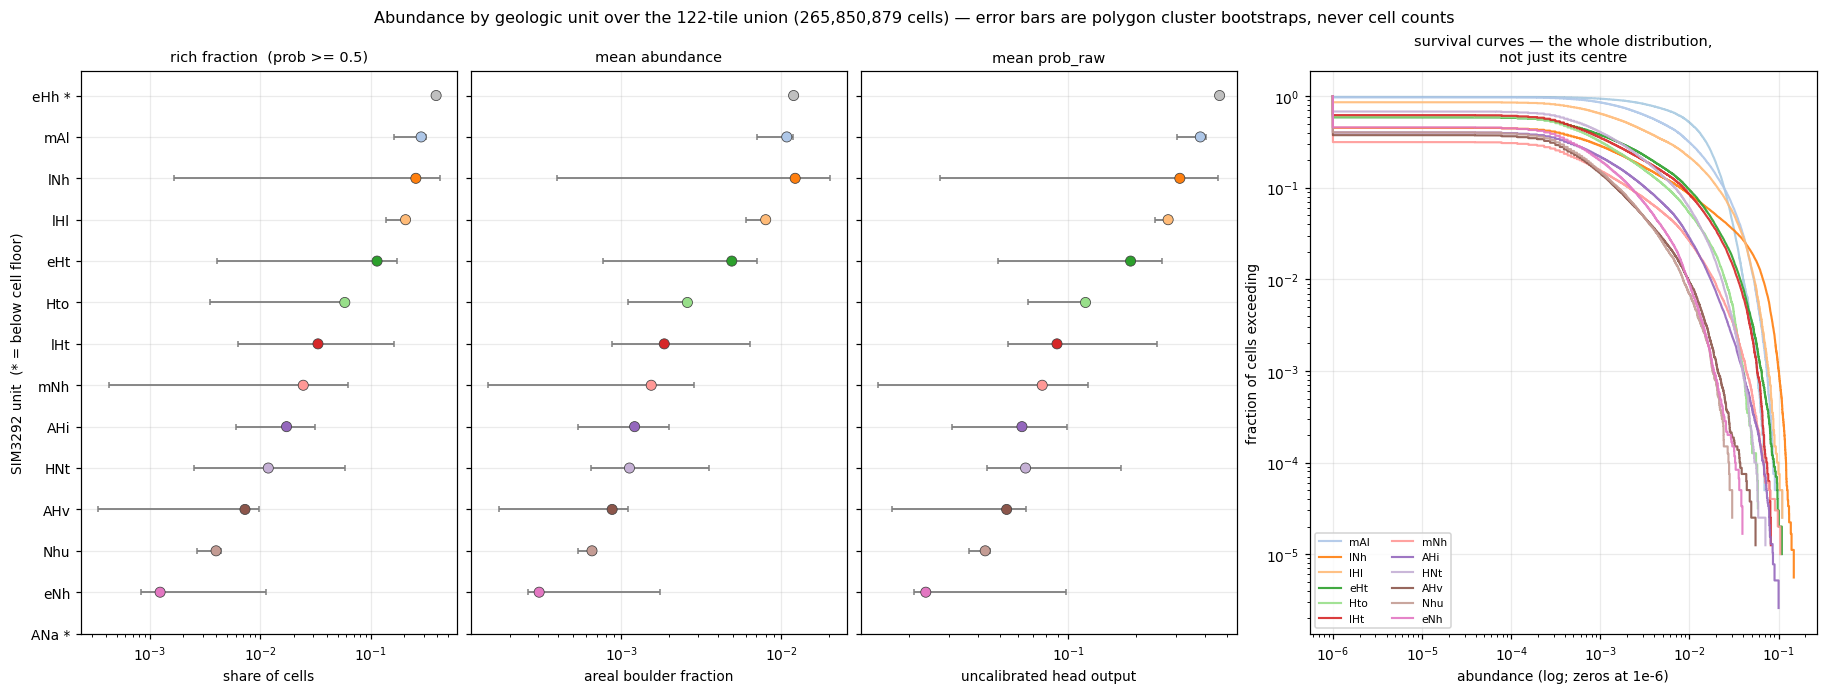

In [10]:
# Figure 2: the ranking on all three targets, plus the ECDFs behind it.
fig, axes = plt.subplots(1, 4, figsize=(16.5, 6.2), constrained_layout=True,
                         gridspec_kw={"width_ratios": [1.0, 1.0, 1.0, 1.35]})
y = np.arange(len(units))
lbl = [f"{u}{'' if m else ' *'}" for u, m in zip(units.Unit, units.reportable)]

for ax, stat, title, xlabel in (
        (axes[0], "rich_frac", "rich fraction  (prob >= 0.5)", "share of cells"),
        (axes[1], "ab_mean", "mean abundance", "areal boulder fraction"),
        (axes[2], "praw_mean", "mean prob_raw", "uncalibrated head output")):
    d = ci[ci.stat == stat].set_index("Unit").loc[units.Unit]
    ok = units.reportable.values
    ax.errorbar(d.point.values, y,
                xerr=[np.nan_to_num(d.point.values - d.lo.values, nan=0.0),
                      np.nan_to_num(d.hi.values - d.point.values, nan=0.0)],
                fmt="none", ecolor="0.5", elinewidth=1.2, capsize=2)
    ax.scatter(d.point.values, y, s=44, zorder=3,
               c=[colors[u] if m else "0.75" for u, m in zip(units.Unit, ok)],
               edgecolor="0.25", linewidth=0.5)
    ax.set_yticks(y); ax.set_yticklabels(lbl if ax is axes[0] else [])
    ax.invert_yaxis()
    ax.set_xscale("log")
    ax.set_title(title, fontsize=9.5)
    ax.set_xlabel(xlabel)
axes[0].set_ylabel("SIM3292 unit  (* = below cell floor)")

axe = axes[3]
for u in units.Unit:
    idx = [i for i in poly[poly.Unit == u].poly if i in ecdf]
    if not idx:
        continue
    v = np.sort(np.concatenate([ecdf[i] for i in idx]))
    q = np.linspace(0, 1, v.size, endpoint=False)
    axe.step(np.maximum(v, 1e-6), 1 - q, where="post", lw=1.4, color=colors[u],
             alpha=0.9 if u in rng_units else 0.35,
             label=u if u in rng_units else None)
axe.set_xscale("log"); axe.set_yscale("log")
axe.set_xlabel("abundance (log; zeros at 1e-6)")
axe.set_ylabel("fraction of cells exceeding")
axe.set_title("survival curves — the whole distribution,\nnot just its centre", fontsize=9.5)
axe.legend(fontsize=7, ncol=2, loc="lower left", framealpha=0.85)
fig.suptitle(f"Abundance by geologic unit over the {tg.meta['n_union_tiles']}-tile union "
             f"({tg.n_finite:,} cells) — error bars are polygon cluster bootstraps, "
             f"never cell counts", fontsize=10.5)
fig.savefig(FIG / "30_geology_pooled.png", bbox_inches="tight")
plt.show()


## §3 — Per-polygon breakdown and the variance decomposition (ruling 9b)

This is the section that answers whether **"unit" is even the right explanatory variable**, or
whether within-unit regional variation dominates.

The three-level split (`mv.nested_variance_decomposition`, exact from per-polygon moments):

* **between-unit** — the part a unit label explains;
* **within-unit-between-polygon** — different polygons of the *same* unit disagreeing;
* **within-polygon** — cell-to-cell variation inside one polygon.

PLAN_MapValidation §10 named the negative in advance: *if within-unit-between-polygon variance
dominates between-unit variance, geologic unit is not a useful predictor of boulder abundance
at this scale, and that is a publishable negative.*

⚠ Read the within-polygon share with the standing caveat in mind: the striping artifact lives
at exactly that scale, so a large within-polygon share is **not** evidence of geologic
heterogeneity.


In [11]:
mapped = poly[poly.n_cells > 0].copy()
for name in ("ab", "praw", "rich"):
    mapped[f"{name}_mean"] = mapped[f"{name}_sum"] / mapped.n_cells

vd = {}
for name, label in (("ab", "abundance"), ("praw", "prob_raw"), ("rich", "rich flag")):
    vd[label] = mv.nested_variance_decomposition(
        mapped.Unit.values, mapped.n_cells.values,
        mapped[f"{name}_sum"].values, mapped[f"{name}_sumsq"].values)

vdf = pd.DataFrame(vd).T[["n_units", "n_polygons", "n_cells", "eta2_between_unit",
                          "eta2_within_unit_between_polygon", "eta2_within_polygon",
                          "closure_residual_relative"]]
print("VARIANCE DECOMPOSITION (shares of total sum of squares about the grand mean)")
print(vdf.to_string(formatters={"eta2_between_unit": "{:.4f}".format,
                                "eta2_within_unit_between_polygon": "{:.4f}".format,
                                "eta2_within_polygon": "{:.4f}".format,
                                "closure_residual_relative": "{:.2e}".format,
                                "n_cells": "{:,.0f}".format}))
for label, d in vd.items():
    assert d["closure_residual_relative"] < 1e-6, f"{label}: moments inconsistent"
    ratio = d["eta2_within_unit_between_polygon"] / max(d["eta2_between_unit"], 1e-12)
    verdict = ("WITHIN-UNIT DOMINATES -- unit is a weak predictor at this scale"
               if ratio > 1 else "between-unit exceeds within-unit-between-polygon")
    print(f"\n{label}: between-unit {d['eta2_between_unit']:.4f} vs "
          f"within-unit-between-polygon {d['eta2_within_unit_between_polygon']:.4f} "
          f"(ratio {ratio:.2f}) -> {verdict}")


VARIANCE DECOMPOSITION (shares of total sum of squares about the grand mean)
           n_units  n_polygons     n_cells eta2_between_unit eta2_within_unit_between_polygon eta2_within_polygon closure_residual_relative
abundance     13.0        63.0 265,850,879            0.1147                           0.0701              0.8152                  2.42e-16
prob_raw      13.0        63.0 265,850,879            0.1549                           0.0674              0.7777                  4.27e-16
rich flag     13.0        63.0 265,850,879            0.0851                           0.0393              0.8756                  0.00e+00

abundance: between-unit 0.1147 vs within-unit-between-polygon 0.0701 (ratio 0.61) -> between-unit exceeds within-unit-between-polygon

prob_raw: between-unit 0.1549 vs within-unit-between-polygon 0.0674 (ratio 0.44) -> between-unit exceeds within-unit-between-polygon

rich flag: between-unit 0.0851 vs within-unit-between-polygon 0.0393 (ratio 0.46) -> between-

In [12]:
# The sharpest form of the ruling-9b question: does the RANKING survive being computed
# per polygon instead of per cell? The headline is cell-weighted (a unit's value is a
# statement about its ground), but if a unit's rank depends on which of its polygons happen
# to be large, then the rank is about a region, not about the unit.
pp = (mapped.assign(rich=lambda d: d.rich_sum / d.n_cells,
                    ab=lambda d: d.ab_sum / d.n_cells)
      .groupby("Unit").agg(polys=("poly", "size"),
                           rich_med=("rich", "median"), rich_min=("rich", "min"),
                           rich_max=("rich", "max"), ab_med=("ab", "median")))
cmp_rank = units.set_index("Unit")[["rich_frac", "ab_mean", "n_cells", "reportable"]].join(pp)
cmp_rank["rank_cellweighted"] = cmp_rank.rich_frac.rank(ascending=False)
cmp_rank["rank_polymedian"] = cmp_rank.rich_med.rank(ascending=False)
cmp_rank["rank_shift"] = cmp_rank.rank_polymedian - cmp_rank.rank_cellweighted
cmp_rank["cw_over_med"] = cmp_rank.rich_frac / cmp_rank.rich_med.replace(0, np.nan)
cmp_rank = cmp_rank.sort_values("rank_cellweighted")
print("CELL-WEIGHTED vs PER-POLYGON-MEDIAN ranking (rich fraction)")
print(cmp_rank[["polys", "rich_frac", "rich_med", "rich_min", "rich_max", "cw_over_med",
                "rank_cellweighted", "rank_polymedian", "rank_shift"]].to_string(
      formatters={"rich_frac": "{:.4f}".format, "rich_med": "{:.4f}".format,
                  "rich_min": "{:.4f}".format, "rich_max": "{:.4f}".format,
                  "cw_over_med": "{:,.0f}x".format}))

sub = cmp_rank[cmp_rank.reportable]
rho_rank, p_rank = spearmanr(sub.rich_frac, sub.rich_med)
print(f"\nrank agreement between the two weightings: rho = {rho_rank:+.4f} "
      f"(p = {p_rank:.3f}, n = {len(sub)} reportable units)")
movers = sub.reindex(sub.rank_shift.abs().sort_values(ascending=False).index)
print("\nUNITS WHOSE RANK DEPENDS ON THE WEIGHTING (|rank shift| >= 2):")
for u, r in movers.iterrows():
    if abs(r.rank_shift) < 2:
        continue
    print(f"  {u}: cell-weighted rich {r.rich_frac:.4f} (rank {r.rank_cellweighted:.0f}) vs "
          f"per-polygon median {r.rich_med:.4f} (rank {r.rank_polymedian:.0f}) over "
          f"{r.polys:.0f} polygons spanning {r.rich_min:.4f}-{r.rich_max:.4f}")
    if r.cw_over_med >= 2:
        print(f"     -> cell-weighted is {r.cw_over_med:,.0f}x its TYPICAL polygon, so a few "
              "large polygons carry it: this is one boulder-rich REGION inside the unit, not "
              "a property of the unit.")
    else:
        print("     -> its large polygons are POORER than its typical polygon, so cell "
              "weighting UNDERSTATES the unit relative to its constituent parts.")


CELL-WEIGHTED vs PER-POLYGON-MEDIAN ranking (rich fraction)
      polys rich_frac rich_med rich_min rich_max cw_over_med  rank_cellweighted  rank_polymedian  rank_shift
Unit                                                                                                        
eHh     1.0    0.3892   0.3892   0.3892   0.3892          1x                1.0              1.0         0.0
mAl     2.0    0.2848   0.2405   0.1626   0.3183          1x                2.0              2.0         0.0
lNh     9.0    0.2550   0.0009   0.0000   0.4715        282x                3.0             12.0         9.0
lHl     2.0    0.2058   0.1726   0.1380   0.2071          1x                4.0              3.0        -1.0
eHt     5.0    0.1136   0.0058   0.0007   0.1790         20x                5.0              7.0         2.0
Hto     2.0    0.0580   0.0308   0.0035   0.0581          2x                6.0              4.0        -2.0
lHt     4.0    0.0332   0.0078   0.0061   0.2165          4x        

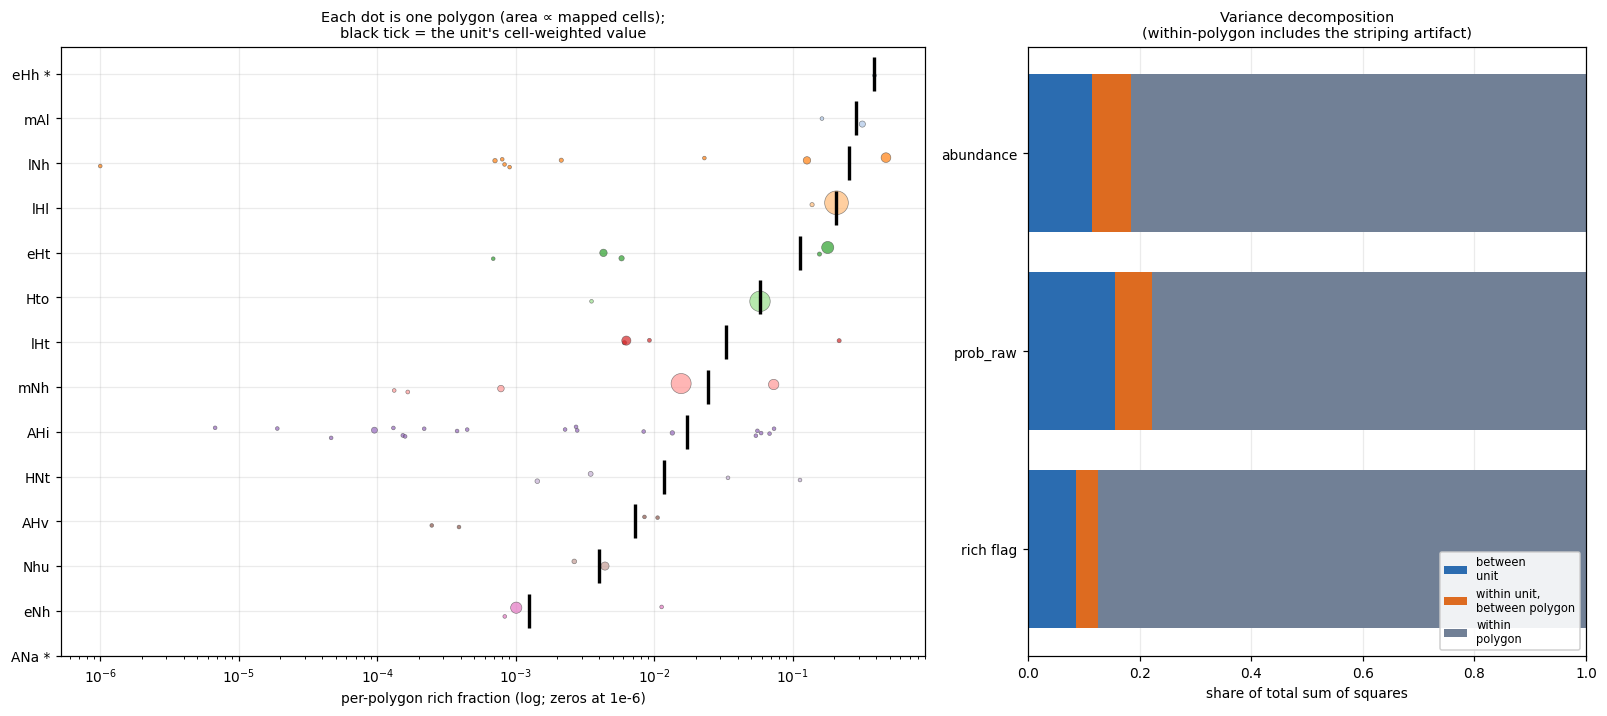

wrote reports\figures\30_geology_perpolygon.csv


In [13]:
# Figure 3: per-polygon spread inside each unit.
fig, axes = plt.subplots(1, 2, figsize=(14.5, 6.4), constrained_layout=True,
                         gridspec_kw={"width_ratios": [1.55, 1.0]})

ax = axes[0]
for k, u in enumerate(units.Unit):
    sub = mapped[mapped.Unit == u]
    if sub.empty:
        continue
    jitter = (np.random.default_rng(k).random(len(sub)) - 0.5) * 0.28
    ax.scatter(np.maximum(sub.rich_mean, 1e-6), np.full(len(sub), k) + jitter,
               s=np.clip(sub.n_cells / 2e5, 6, 240), alpha=0.7, color=colors[u],
               edgecolor="0.3", linewidth=0.4)
    ur = units.loc[units.Unit == u, "rich_frac"].iloc[0]
    ax.plot([max(ur, 1e-6)], [k], marker="|", ms=22, mew=2.2, color="k", zorder=4)
ax.set_yticks(range(len(units)))
ax.set_yticklabels([f"{u}{'' if m else ' *'}" for u, m in zip(units.Unit, units.reportable)])
ax.invert_yaxis()
ax.set_xscale("log")
ax.set_xlabel("per-polygon rich fraction (log; zeros at 1e-6)")
ax.set_title("Each dot is one polygon (area ∝ mapped cells);\n"
             "black tick = the unit's cell-weighted value", fontsize=9.5)

ax = axes[1]
comp = ["eta2_between_unit", "eta2_within_unit_between_polygon", "eta2_within_polygon"]
names = ["between\nunit", "within unit,\nbetween polygon", "within\npolygon"]
left = np.zeros(len(vdf))
for c, nm, col in zip(comp, names, ("#2b6cb0", "#dd6b20", "#718096")):
    ax.barh(range(len(vdf)), vdf[c].values, left=left, color=col, label=nm)
    left = left + vdf[c].values
ax.set_yticks(range(len(vdf))); ax.set_yticklabels(vdf.index)
ax.invert_yaxis()
ax.set_xlim(0, 1)
ax.set_xlabel("share of total sum of squares")
ax.set_title("Variance decomposition\n(within-polygon includes the striping artifact)",
             fontsize=9.5)
ax.legend(fontsize=7.5, loc="lower right", framealpha=0.9)
fig.savefig(FIG / "30_geology_perpolygon.png", bbox_inches="tight")
plt.show()

out_csv = FIG / "30_geology_perpolygon.csv"
mapped.drop(columns=[c for c in mapped.columns if c.endswith("_sumsq")]).to_csv(
    out_csv, index=False)
print("wrote", out_csv.relative_to(REPO))


## §4 — Abundance vs stratigraphic age

The geologically interesting axis. Unit codes carry epoch (`eN`/`mN`/`lN`/`eH`/`lH`/`A`…), so
each unit gets a rank on an ordinal age scale (`mv.stratigraphic_rank`, increasing = younger).

**Two readings, both plausible in advance:** older surfaces should be *boulder-poor* if boulders
break down over time — unless **exhumation** dominates, in which case ancient terrain can be
boulder-rich. Which way it comes out is the result.

⚠ **Two-epoch units (`AHi`, `AHv`, `ANa`, `HNt`) are flagged.** An `AHi` unit is not "age 5.5",
it is *undated within a ~3 Gyr window*, so the trend is reported **with and without** them. And
the axis is **ordinal** — epoch boundaries are not evenly spaced in time — so a rank
correlation is the only honest statistic here, not a slope.


In [14]:
age = units[units.reportable & np.isfinite(units.age_rank)].copy()
print(f"{len(age)} reportable units carry a parsed age rank; "
      f"{int(age.spans_epochs.sum())} span two epochs")

for label, sub in (("all reportable units", age),
                   ("single-epoch units only", age[~age.spans_epochs])):
    line = [f"{label:26s} n={len(sub):2d}"]
    for stat in ("rich_frac", "ab_mean", "praw_mean"):
        rho, p = spearmanr(sub.age_rank, sub[stat])
        line.append(f"{stat}: rho={rho:+.3f} (p={p:.3f})")
    print("  " + "   ".join(line))

# ...and on the per-polygon-median weighting from §3, which is the weighting that does not
# let one large polygon speak for a unit. If the age trend only exists under cell weighting,
# it is a statement about a few regions.
age_pm = age.set_index("Unit").join(pp[["rich_med", "ab_med"]])
for label, sub in (("all reportable units", age_pm),
                   ("single-epoch units only", age_pm[~age_pm.spans_epochs])):
    line = [f"{label:26s} n={len(sub):2d}"]
    for stat in ("rich_med", "ab_med"):
        rho, p = spearmanr(sub.age_rank, sub[stat])
        line.append(f"{stat}: rho={rho:+.3f} (p={p:.3f})")
    print("  [per-polygon median] " + "   ".join(line))

# cell-weighted, at epoch resolution -- the unit-level rho above weights a 48k-cell unit the
# same as an 82M-cell one, which is a different question from "is younger ground rockier".
ep = mapped.copy()
ep["age_rank"] = ep.Unit.map(lambda u: mv.stratigraphic_rank(u)["rank"])
ep["age_label"] = ep.Unit.map(lambda u: mv.stratigraphic_rank(u)["label"])
ep["spans"] = ep.Unit.map(lambda u: mv.stratigraphic_rank(u)["spans"])
byep = ep.groupby(["age_rank", "age_label"], as_index=False).agg(
    units=("Unit", "nunique"), polys=("poly", "size"), n_cells=("n_cells", "sum"),
    rich_sum=("rich_sum", "sum"), ab_sum=("ab_sum", "sum"))
byep["rich_frac"] = byep.rich_sum / byep.n_cells
byep["ab_mean"] = byep.ab_sum / byep.n_cells
byep = byep.sort_values("age_rank")
print("\nCELL-WEIGHTED, by epoch (oldest first):")
print(byep[["age_rank", "age_label", "units", "polys", "n_cells", "ab_mean", "rich_frac"]]
      .to_string(index=False, formatters={"n_cells": "{:,.0f}".format,
                                          "ab_mean": "{:.5f}".format,
                                          "rich_frac": "{:.4f}".format}))


12 reportable units carry a parsed age rank; 3 span two epochs
  all reportable units       n=12   rich_frac: rho=+0.425 (p=0.168)   ab_mean: rho=+0.369 (p=0.238)   praw_mean: rho=+0.387 (p=0.214)
  single-epoch units only    n= 9   rich_frac: rho=+0.740 (p=0.023)   ab_mean: rho=+0.655 (p=0.055)   praw_mean: rho=+0.740 (p=0.023)
  [per-polygon median] all reportable units       n=12   rich_med: rho=+0.608 (p=0.036)   ab_med: rho=+0.541 (p=0.069)
  [per-polygon median] single-epoch units only    n= 9   rich_med: rho=+0.866 (p=0.003)   ab_med: rho=+0.866 (p=0.003)

CELL-WEIGHTED, by epoch (oldest first):
 age_rank             age_label  units  polys    n_cells ab_mean rich_frac
      1.0        Early Noachian      1      3 11,827,651 0.00031    0.0012
      2.0       Middle Noachian      1      5 49,886,949 0.00154    0.0244
      2.0  Noachian (undivided)      1      2  7,652,383 0.00065    0.0040
      3.0         Late Noachian      1      9 17,387,190 0.01227    0.2550
      3.5    He

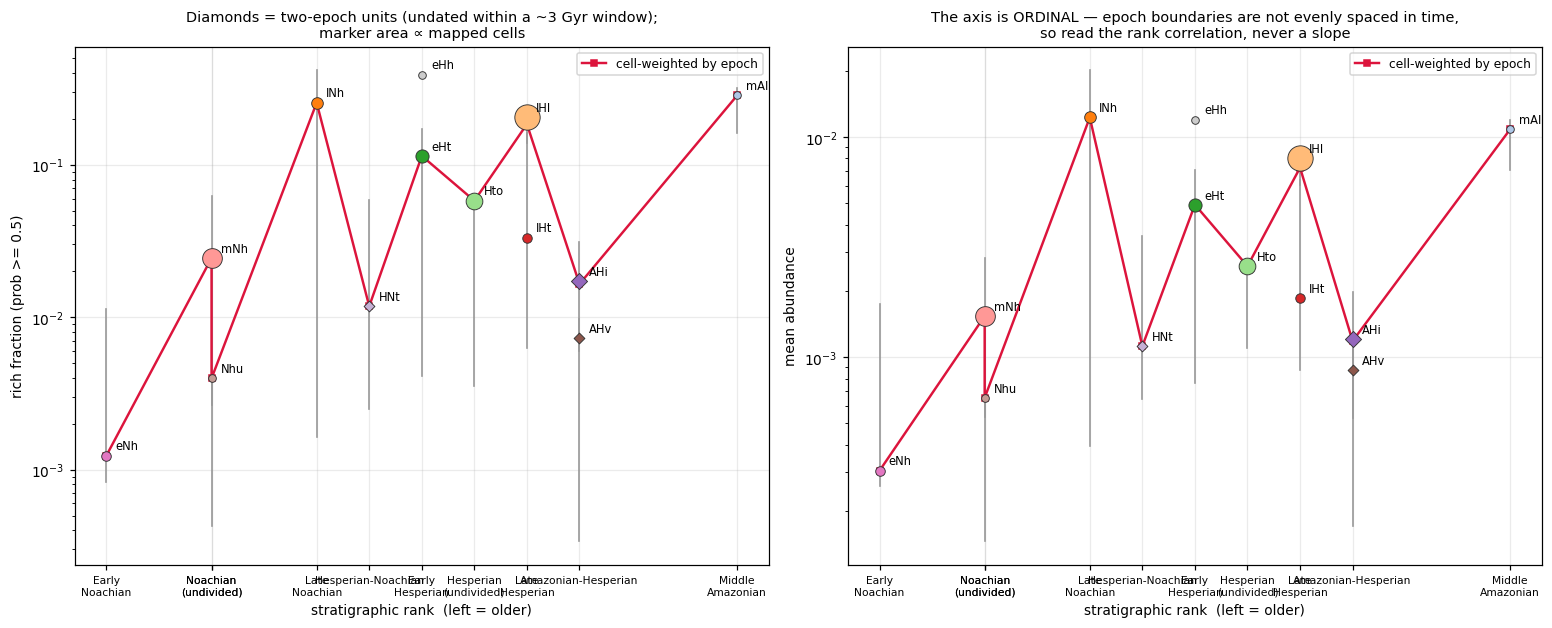

In [15]:
# Figure 4: abundance vs age.
fig, axes = plt.subplots(1, 2, figsize=(14.0, 5.6), constrained_layout=True)

for ax, stat, ylabel in ((axes[0], "rich_frac", "rich fraction (prob >= 0.5)"),
                         (axes[1], "ab_mean", "mean abundance")):
    d = ci[ci.stat == stat].set_index("Unit")
    for _, r in units.iterrows():
        if not np.isfinite(r.age_rank):
            continue
        c = colors[r.Unit]
        lo, hi = d.loc[r.Unit, "lo"], d.loc[r.Unit, "hi"]
        pt = max(r[stat], 1e-6)
        if np.isfinite(lo) and np.isfinite(hi):
            ax.plot([r.age_rank, r.age_rank], [max(lo, 1e-6), max(hi, 1e-6)],
                    color="0.6", lw=1.1, zorder=1)
        ax.scatter([r.age_rank], [pt], s=np.clip(r.n_cells / 3e5, 25, 340),
                   color=c if r.reportable else "0.8",
                   marker="D" if r.spans_epochs else "o",
                   edgecolor="0.2", linewidth=0.6, zorder=3)
        ax.annotate(r.Unit, (r.age_rank, pt), textcoords="offset points",
                    xytext=(6, 4), fontsize=7.5)
    # the cell-weighted epoch track
    ax.plot(byep.age_rank, np.maximum(byep[stat], 1e-6), color="crimson", lw=1.6,
            marker="s", ms=4, zorder=2, label="cell-weighted by epoch")
    ax.set_yscale("log")
    ax.set_xlabel("stratigraphic rank  (left = older)")
    ax.set_ylabel(ylabel)
    ax.set_xticks(sorted(byep.age_rank))
    ax.set_xticklabels([l.replace(" ", "\n") for l in byep.age_label], fontsize=7)
    ax.legend(fontsize=8, loc="best")
axes[0].set_title("Diamonds = two-epoch units (undated within a ~3 Gyr window);\n"
                  "marker area ∝ mapped cells", fontsize=9.5)
axes[1].set_title("The axis is ORDINAL — epoch boundaries are not evenly spaced in time,\n"
                  "so read the rank correlation, never a slope", fontsize=9.5)
fig.savefig(FIG / "30_geology_byage.png", bbox_inches="tight")
plt.show()


## §5 — The honest limits

1. **The striping artifact is present and uncorrected**, by ruling. **Every contrast above is an
   upper bound on the geologic signal.** In particular the *within-polygon* variance share in §3
   contains the artifact, so it is not a measure of geologic heterogeneity, and any unit whose
   footprint happens to coincide with a few CTX source frames carries that frame structure into
   its mean. Notebook 32 is the entry point to quantifying this.

2. **`abundance` is size-floor-referenced.** Boulders above a per-image floor of 1.41–2.66 m
   diameter, mixed over 20 floors / 38 images. A unit difference could in principle be a
   difference in the *size distribution* rather than in total rockiness.

3. **Truth coverage is very uneven across these units.** 23 of the 39-image training cohort sit
   inside the original 26-tile circum-Chryse block; the western and southern extension has
   almost none. So the units that live mostly in the extension are **extrapolation**, and their
   ranking is a claim about the model's generalisation as much as about their geology.

4. **Unit boundaries are not independent of topography**, and the map may respond to topography
   directly (slope, shadowing, dust cover). A lowland-vs-highland contrast is therefore partly
   confounded with an illumination-and-slope contrast by construction.

5. **`AHi` (impact) overlaps notebook 31's craters by construction** — the two experiments are
   not independent evidence about the same terrain.

6. **The age axis is ordinal and the units are areal, not dated.** Two-epoch units are undated
   within a ~3 Gyr window; §4 reports the trend with and without them for that reason.

7. **Polygons are the inferential unit, and there are few of them.** The CIs above come from
   resampling at most 26 polygons (`AHi`) and as few as 1. A unit with one mapped polygon has no
   CI at all — reported as undefined, never as zero width.

8. **The headline ranking is cell-weighted, and for some units that is a statement about a
   region rather than about the unit.** §3 quantifies this: a unit whose cell-weighted value is
   orders of magnitude above its typical polygon is being carried by a few large polygons. Any
   sentence of the form "unit X is boulder-rich" must be checked against its per-polygon spread
   before it is written down.


In [16]:
summary = {
    "union_tiles": int(tg.meta["n_union_tiles"]),
    "union_finite_cells": int(tg.n_finite),
    "geology": {k: rep[k] for k in ("source_polygons", "source_units", "polygons", "units",
                                    "partition_closure", "repaired")},
    "min_cells_unit": int(mv.MIN_CELLS_UNIT),
    "reportable_units": sorted(units[units.reportable].Unit),
    "flagged_units": sorted(units[~units.reportable].Unit),
    "ranking_on_rich_fraction": [
        {"unit": r.Unit, "rich_frac": float(r.rich_frac), "ab_mean": float(r.ab_mean),
         "n_cells": int(r.n_cells), "age": r.age_label, "spans_epochs": bool(r.spans_epochs)}
        for _, r in units[units.reportable].iterrows()],
    "variance_decomposition": {k: {kk: float(vv) if isinstance(vv, (int, float)) else vv
                                   for kk, vv in v.items()} for k, v in vd.items()},
}
out = FIG / "30_geology_summary.json"
out.write_text(json.dumps(summary, indent=2), encoding="utf-8")
print("wrote", out.relative_to(REPO))
print(json.dumps({k: summary[k] for k in ("union_tiles", "union_finite_cells",
                                          "reportable_units", "flagged_units")}, indent=2))


wrote reports\figures\30_geology_summary.json
{
  "union_tiles": 122,
  "union_finite_cells": 265850879,
  "reportable_units": [
    "AHi",
    "AHv",
    "HNt",
    "Hto",
    "Nhu",
    "eHt",
    "eNh",
    "lHl",
    "lHt",
    "lNh",
    "mAl",
    "mNh"
  ],
  "flagged_units": [
    "ANa",
    "eHh"
  ]
}
